IHD with 36 sujects, 

In [356]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import os
import warnings
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import f_regression

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)


plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.loc'] = 'best'

plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 8  # Taille des labels des xticks
plt.rcParams['ytick.labelsize'] = 8  # Taille des labels des yticks
plt.rcParams['legend.fontsize'] = 8 # Taille des labels de la légende
plt.rcParams['figure.titlesize'] = 12  # Taille du titre de la figure
plt.rcParams['axes.titlesize'] = 12  # Taille du titre des sous-graphes
plt.rcParams['axes.labelsize'] = 10  # Taille des labels des axes


pathfile=r'/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC/'
# pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
pathfig=pathfile+'figures/'
os.chdir(pathfile)

addtotitle='_03022026_woMA_for_RD_MD_AD_FA' # to specify the version of the data

metricsDTI='RD' # to specify the DTI metric to use for the analysis FA, RD, AD, MD

### change 36 to 42 to include the 6 subjects without IHD in the analysis
limitsubject=36 # to select only the 36 subjects with IHD


#_03022026_AllSubjects
Aging_INDICES_all = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler
scaler = RobustScaler()


DTI_all=np.zeros((limitsubject, 98, 7))  # 10 DTI metrics
DTI_all_scaled=np.zeros((limitsubject, 98, 7))  # 10 DTI metrics

for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_{metricsDTI}{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")

    DTI_all[:,:,i]=dfCCx[:limitsubject].values  ## une variable DTI of shape subjects x nodes x n CC
    
    DTI_all_scaled[:,:,i]=scaler.fit_transform(dfCCx[:limitsubject].values)  ## une variable DTI of shape subjects x nodes x n CC

 # target var

import seaborn as sns
selection=[0,limitsubject] # to select only the subjects with IHD
Aging_INDICES=Aging_INDICES_all[selection[0]:selection[1]] # 

DTI=DTI_all[selection[0]:selection[1],:,:]  # 

DTI_scaled=DTI_all_scaled[selection[0]:selection[1],:,:]  

age = Aging_INDICES['age'].values

### ATTENTION CIBLE IHD REMPLACANT JND
ihd = Aging_INDICES['IHD'].values
jnd = Aging_INDICES['JND_P'].values

# DTI values 

labels = [0,1]

Aging_INDICES['IHD_group'] = pd.qcut(Aging_INDICES['IHD'], q=2, labels=labels)
Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)

age_grouped = Aging_INDICES['group_O']
IHD_grouped = Aging_INDICES['IHD_group']
JND_grouped = Aging_INDICES['JND_group']

Aging_INDICES=Aging_INDICES[0:limitsubject] # only the subjects with IHD

print('length of Aging_INDICES:', len(Aging_INDICES))

DTI_scaled_saved=DTI_scaled.copy() # to keep a copy of the original DTI values before adjustment


##############

import statsmodels.api as sm

DTI_adjusted = np.zeros_like(DTI_scaled)  # pour stocker les données DTI ajustées

for cc in range(7):
    for seg in range(98):
        data = DTI_scaled[:,seg,cc]  # on prend les données DTI du CC1 pour l'exemple
        data_adjusted = data.copy()
        X = sm.add_constant(age)
        y = data
        model = sm.OLS(y, X)
        results = model.fit()   
        residuals = results.resid
        data_adjusted = residuals

        DTI_adjusted[:,seg,cc] = data_adjusted  # stocker les données ajustées  


length of Aging_INDICES: 36


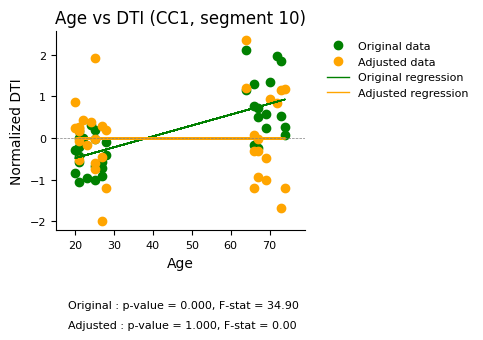

In [357]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats



# Create a figure
fig1, ax1 = plt.subplots(figsize=(5,4))

# Plot the original data
ax1.plot(age, DTI_scaled_saved[:, 60, 0], 'o', label='Original data', color='green')

# Plot the adjusted data
ax1.plot(age, DTI_adjusted[:, 50, 6], 'o', label='Adjusted data', color='orange')

slope_orig, intercept_orig, r_value_orig, p_value_orig, std_err_orig = stats.linregress(age, DTI_scaled_saved[:, 60, 0])
line_orig = slope_orig * age + intercept_orig
ax1.plot(age, line_orig, label='Original regression', color='green',lw=1)
# Calculate and plot regression lines for adjusted data
slope_adj, intercept_adj, r_value_adj, p_value_adj, std_err_adj = stats.linregress(age, DTI_adjusted[:, 50, 6])
line_adj = slope_adj * age + intercept_adj
ax1.plot(age, line_adj,  label='Adjusted regression', color='orange',lw=1)

n = len(age)
F_stat_orig = (r_value_orig**2 / (1 - r_value_orig**2)) * (n - 2)
F_stat_adj = (r_value_adj**2 / (1 - r_value_adj**2)) * (n - 2)

# Add p-values and F-statistics as text on the figure
ax1.text(0.05, 0.95-1.3, f'Original : p-value = {p_value_orig:.3f}, F-stat = {F_stat_orig:.2f}',
         transform=ax1.transAxes, fontsize=8, verticalalignment='top')
ax1.text(0.05, 0.90-1.35, f'Adjusted : p-value = {p_value_adj:.3f}, F-stat = {F_stat_adj:.2f}',
         transform=ax1.transAxes, fontsize=8, verticalalignment='top')

ax1.set_title('Age vs DTI (CC1, segment 10)')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(age.min() - 5, age.max() + 5)
ax1.set_xlabel('Age')
ax1.set_ylabel('Normalized DTI')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax1.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

F-value: 12.29629170543671, p-value: 0.0012971267549069566


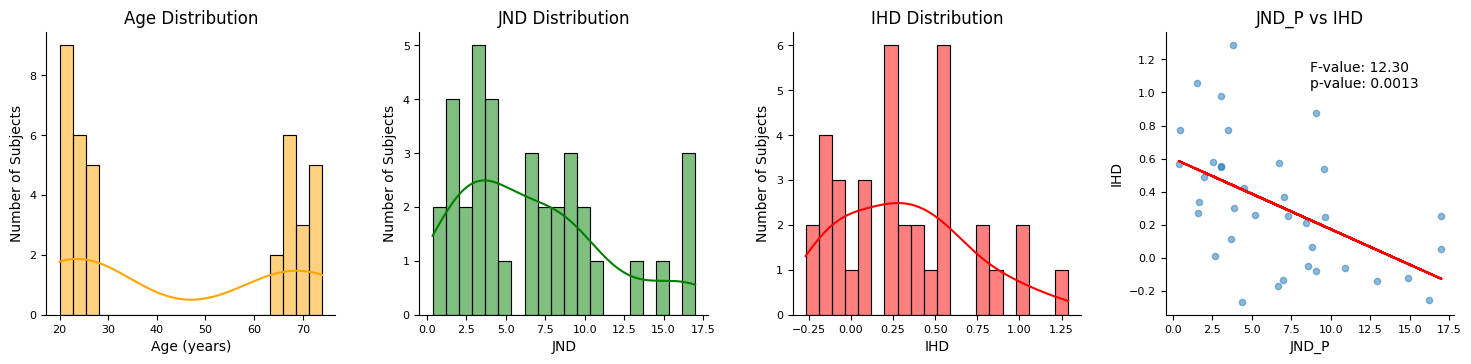

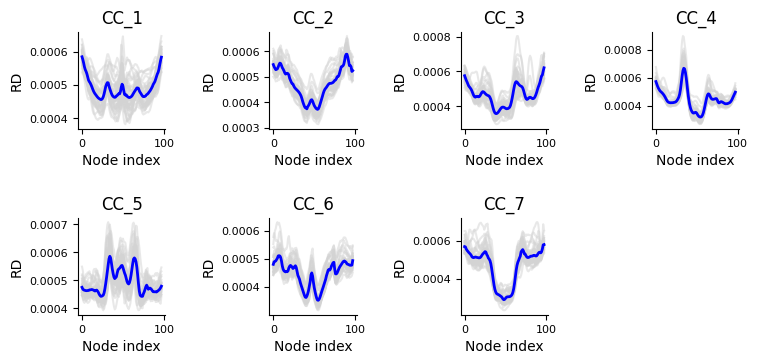

In [358]:
from sklearn.feature_selection import f_regression

fig2, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 4))
axs = axs.flatten()

sns.histplot(age, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND Distribution')
axs[1].set_xlabel('JND')
axs[1].set_ylabel('Number of Subjects')
sns.histplot(ihd, bins=20, ax=axs[2],color='red',kde=True)
axs[2].set_title('IHD Distribution')
axs[2].set_xlabel('IHD')
axs[2].set_ylabel('Number of Subjects')


axs[3].scatter(jnd, ihd, alpha=0.5, s=20)
axs[3].set_title('JND_P vs IHD')
axs[3].set_xlabel('JND_P')
axs[3].set_ylabel('IHD')

coefficients = np.polyfit(jnd, ihd, 1)
polynomial = np.poly1d(coefficients)

f,p=f_regression(jnd.reshape(-1, 1), ihd)

print(f"F-value: {f[0]}, p-value: {p[0]}")
# Tracer les données et la régression linéaire
axs[3].plot(jnd, polynomial(jnd), color='red', label='Régression linéaire')
axs[3].text(0.5, 0.9, f'F-value: {f[0]:.2f}\np-value: {p[0]:.4f}', transform=axs[3].transAxes, fontsize=10, verticalalignment='top')
for i in range(4):
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

fig3, axs = plt.subplots(nrows=2, ncols=4, figsize=(8, 4))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel(metricsDTI)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)


fig3.delaxes(axs[7])
plt.tight_layout(pad=2.0)


Feat selectio based on simple lin regression using f_regression

based on r_regression

In [359]:

####

from sklearn.feature_selection import r_regression, f_regression

r_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_best_features_ihd_cc_allCC = np.zeros((7,10), dtype=int)

f_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
f_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)
f_reg_best_features_ihd_cc_allCC = np.zeros((7,10), dtype=int)

r_reg_age = np.zeros((7,98))
r_reg_jnd = np.zeros((7,98))
r_reg_ihd = np.zeros((7,98))
p_values_jnd = np.zeros((7,98))
p_values_age = np.zeros((7,98))
p_values_ihd = np.zeros((7,98))

for cc in range(1,8):   

    r_reg_jnd[cc-1,:] = r_regression(DTI_adjusted[:,:,cc-1], jnd)
    r_reg_age[cc-1,:] = r_regression(DTI_adjusted[:,:,cc-1], age)
    r_reg_ihd[cc-1,:] = r_regression(DTI_adjusted[:,:,cc-1], ihd)

    r_reg_best_features_jnd_cc = np.argsort(r_reg_jnd[cc-1,:])
    r_reg_best_features_age_cc = np.argsort(r_reg_age[cc-1,:])
    r_reg_best_features_ihd_cc = np.argsort(r_reg_ihd[cc-1,:])
     
    if metricsDTI=='FA':
        r_reg_best_features_jnd_cc_allCC[cc-1,:]= r_reg_best_features_jnd_cc[:10]
        r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[:10]
        r_reg_best_features_ihd_cc_allCC[cc-1,:] = r_reg_best_features_ihd_cc[-10:]
    else: 
        r_reg_best_features_jnd_cc_allCC[cc-1,:] = r_reg_best_features_jnd_cc[-10:]
        r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[-10:]
        r_reg_best_features_ihd_cc_allCC[cc-1,:] = r_reg_best_features_ihd_cc[:10]
    

    f_statistic_jnd, p_values_jnd[cc-1,:] = f_regression(DTI_adjusted[:,:,cc-1], jnd )
    f_statistic_age, p_values_age[cc-1,:] = f_regression(DTI_adjusted[:,:,cc-1], age )
    f_statistic_ihd, p_values_ihd[cc-1,:] = f_regression(DTI_adjusted[:,:,cc-1], ihd )
    
    f_reg_best_features_jnd_cc = np.argsort(p_values_jnd[cc-1,:])[:97]
    f_reg_best_features_age_cc = np.argsort(p_values_age[cc-1,:])[:97]
    f_reg_best_features_ihd_cc = np.argsort(p_values_ihd[cc-1,:])[:97]
    f_reg_best_features_jnd_cc_allCC[cc-1,:]= f_reg_best_features_jnd_cc[:10]
    f_reg_best_features_age_cc_allCC[cc-1,:] = f_reg_best_features_age_cc[:10]
    f_reg_best_features_ihd_cc_allCC[cc-1,:] = f_reg_best_features_ihd_cc[:10]



bestfeat_ihd_r=r_reg_best_features_ihd_cc_allCC
bestfeat_ihd_f=f_reg_best_features_ihd_cc_allCC

bestfeat_jnd_r=r_reg_best_features_jnd_cc_allCC
bestfeat_jnd_f=f_reg_best_features_jnd_cc_allCC

bestfeat_age_r=r_reg_best_features_age_cc_allCC
bestfeat_age_f=f_reg_best_features_age_cc_allCC


bestfeat_jnd_r

array([[77, 83, 80, 24, 79, 26, 82, 25, 94, 49],
       [20, 88,  7, 33, 80, 85, 96, 81, 86, 87],
       [67,  8,  7,  6,  5,  4,  3,  0,  2,  1],
       [ 2, 48,  0, 63, 59,  1, 62, 60, 61, 97],
       [22, 61, 16, 58,  0, 60, 19, 59, 18, 17],
       [75, 56, 66, 92, 93, 54, 53, 55, 52, 68],
       [40, 52, 48, 38, 46, 47, 42, 41, 37, 36]])

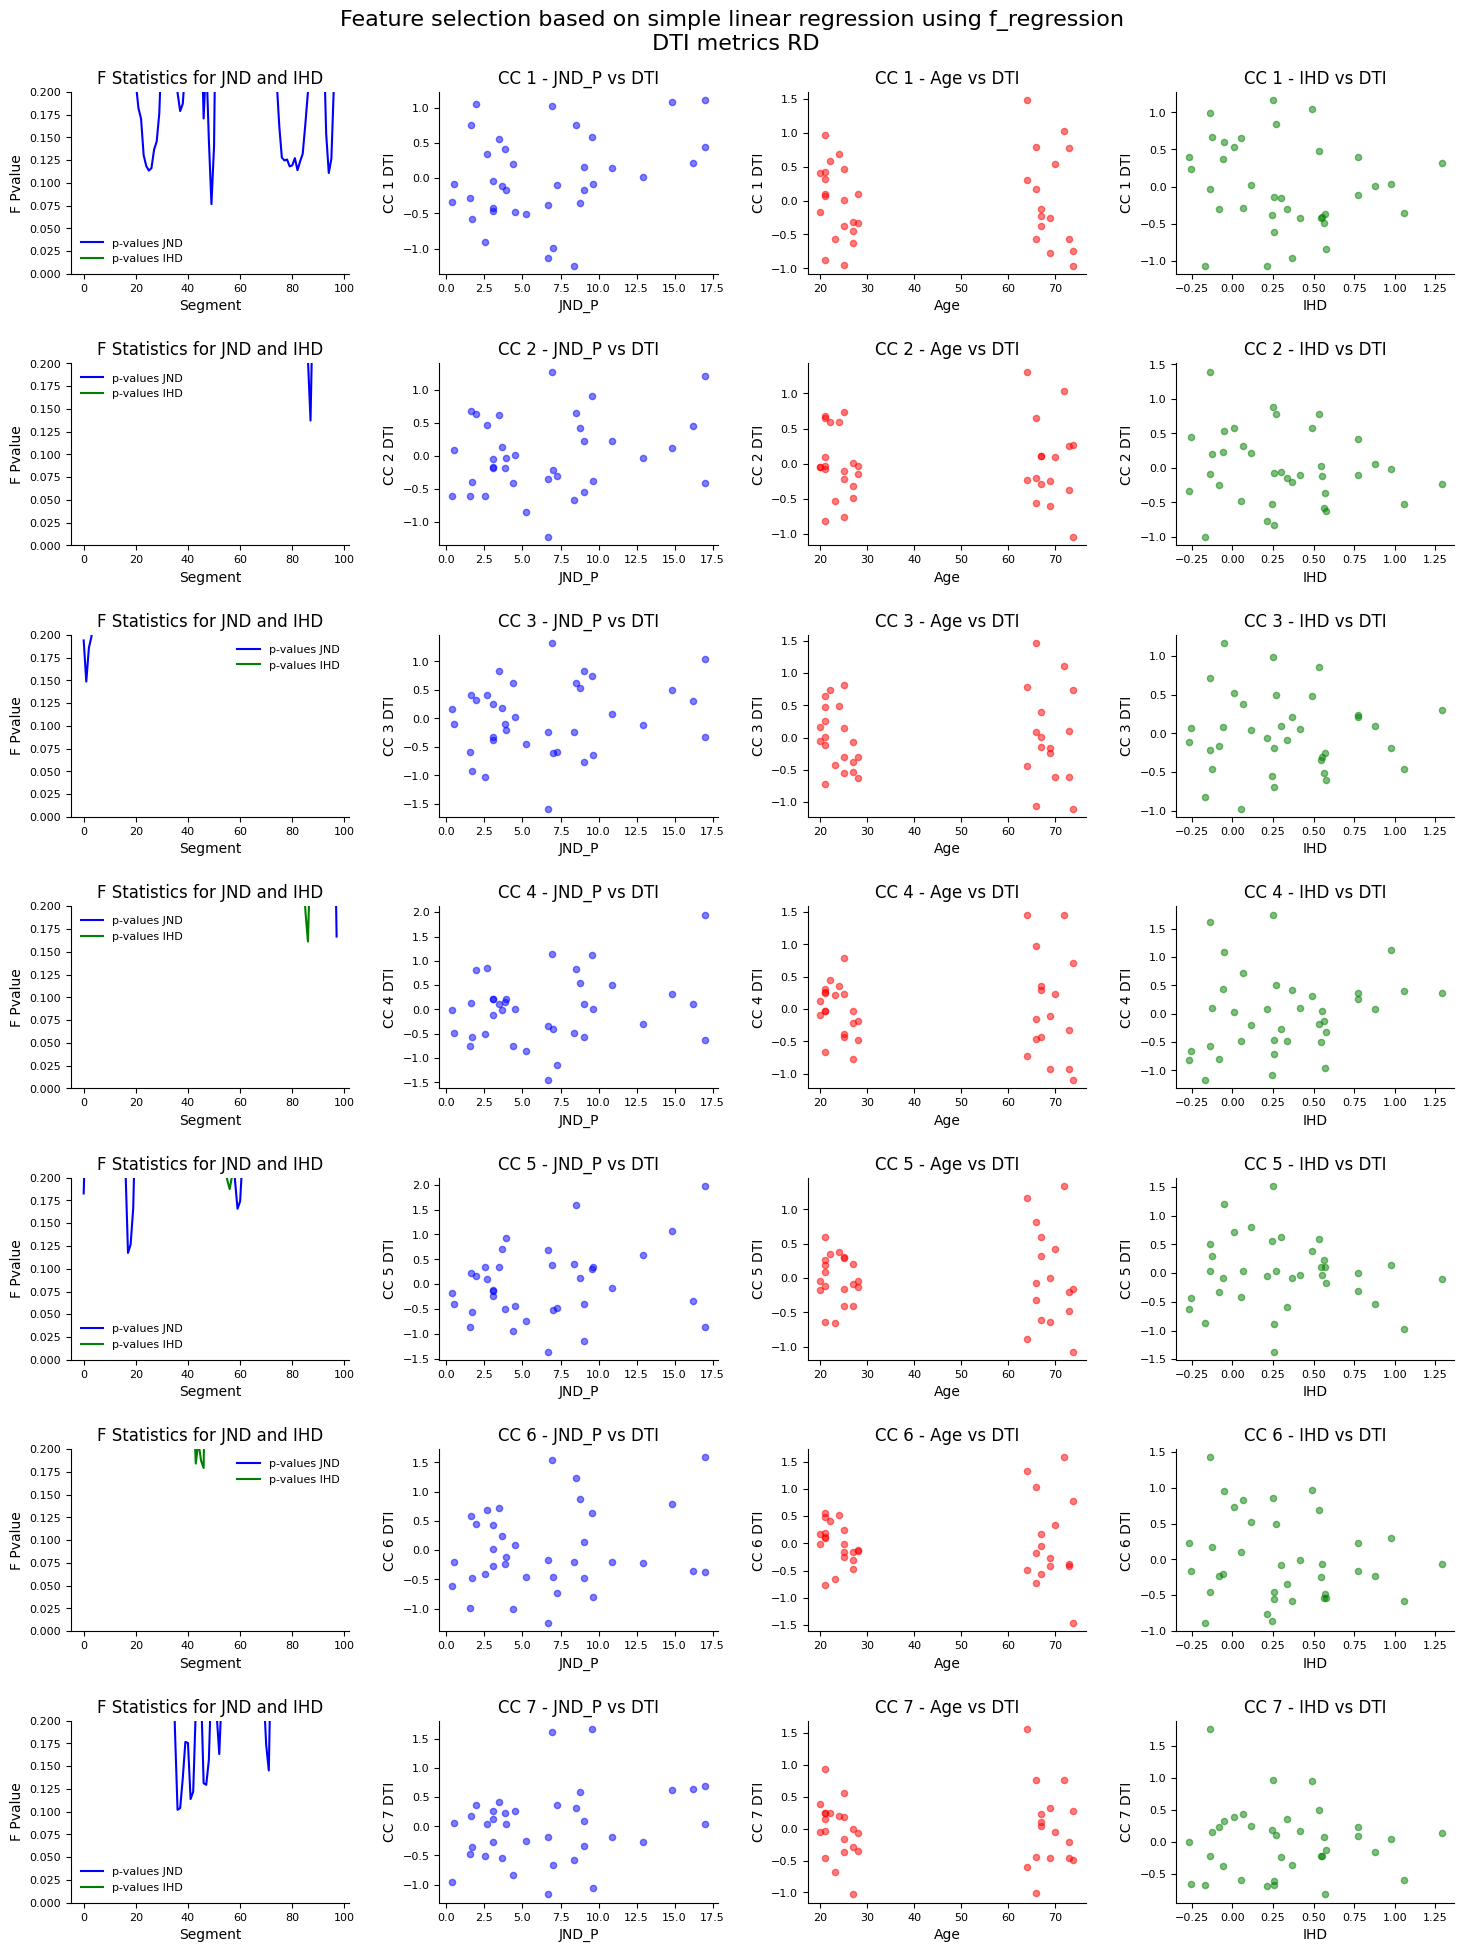

In [360]:
## F statistic P values

fig4, axs = plt.subplots(nrows=7, ncols=4, figsize=(15, 20))

for cc in range(1,8):   

    axs[cc-1,0].plot(p_values_jnd[cc-1,:], color='blue', label='p-values JND')
    axs[cc-1,0].plot(p_values_ihd[cc-1,:], color='green', label='p-values IHD')
    axs[cc-1,0].set_ylim(0,0.2)
    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('F Pvalue')   
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('F Statistics for JND and IHD')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)
    axs[cc-1,0].axhline(0, color='gray', linestyle='--', linewidth=0.5)

    axs[cc-1,1].scatter(jnd, DTI_adjusted[:,bestfeat_jnd_f[cc-1,:] ,cc-1].mean(axis=1), color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_adjusted[:,bestfeat_age_f[cc-1,:] ,cc-1].mean(axis=1), color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,3].scatter(ihd, DTI_adjusted[:,bestfeat_ihd_f[cc-1,:] ,cc-1].mean(axis=1), color='green', label='Données', alpha=0.5, s=20)

    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,3].set_xlabel('IHD')
    axs[cc-1,3].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,3].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,3].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')
    axs[cc-1,3].set_title(f'CC {cc} - IHD vs DTI')

fig4.suptitle('Feature selection based on simple linear regression using f_regression\n DTI metrics {}'.format(metricsDTI), fontsize=16)
    
plt.tight_layout(pad=2.0) 

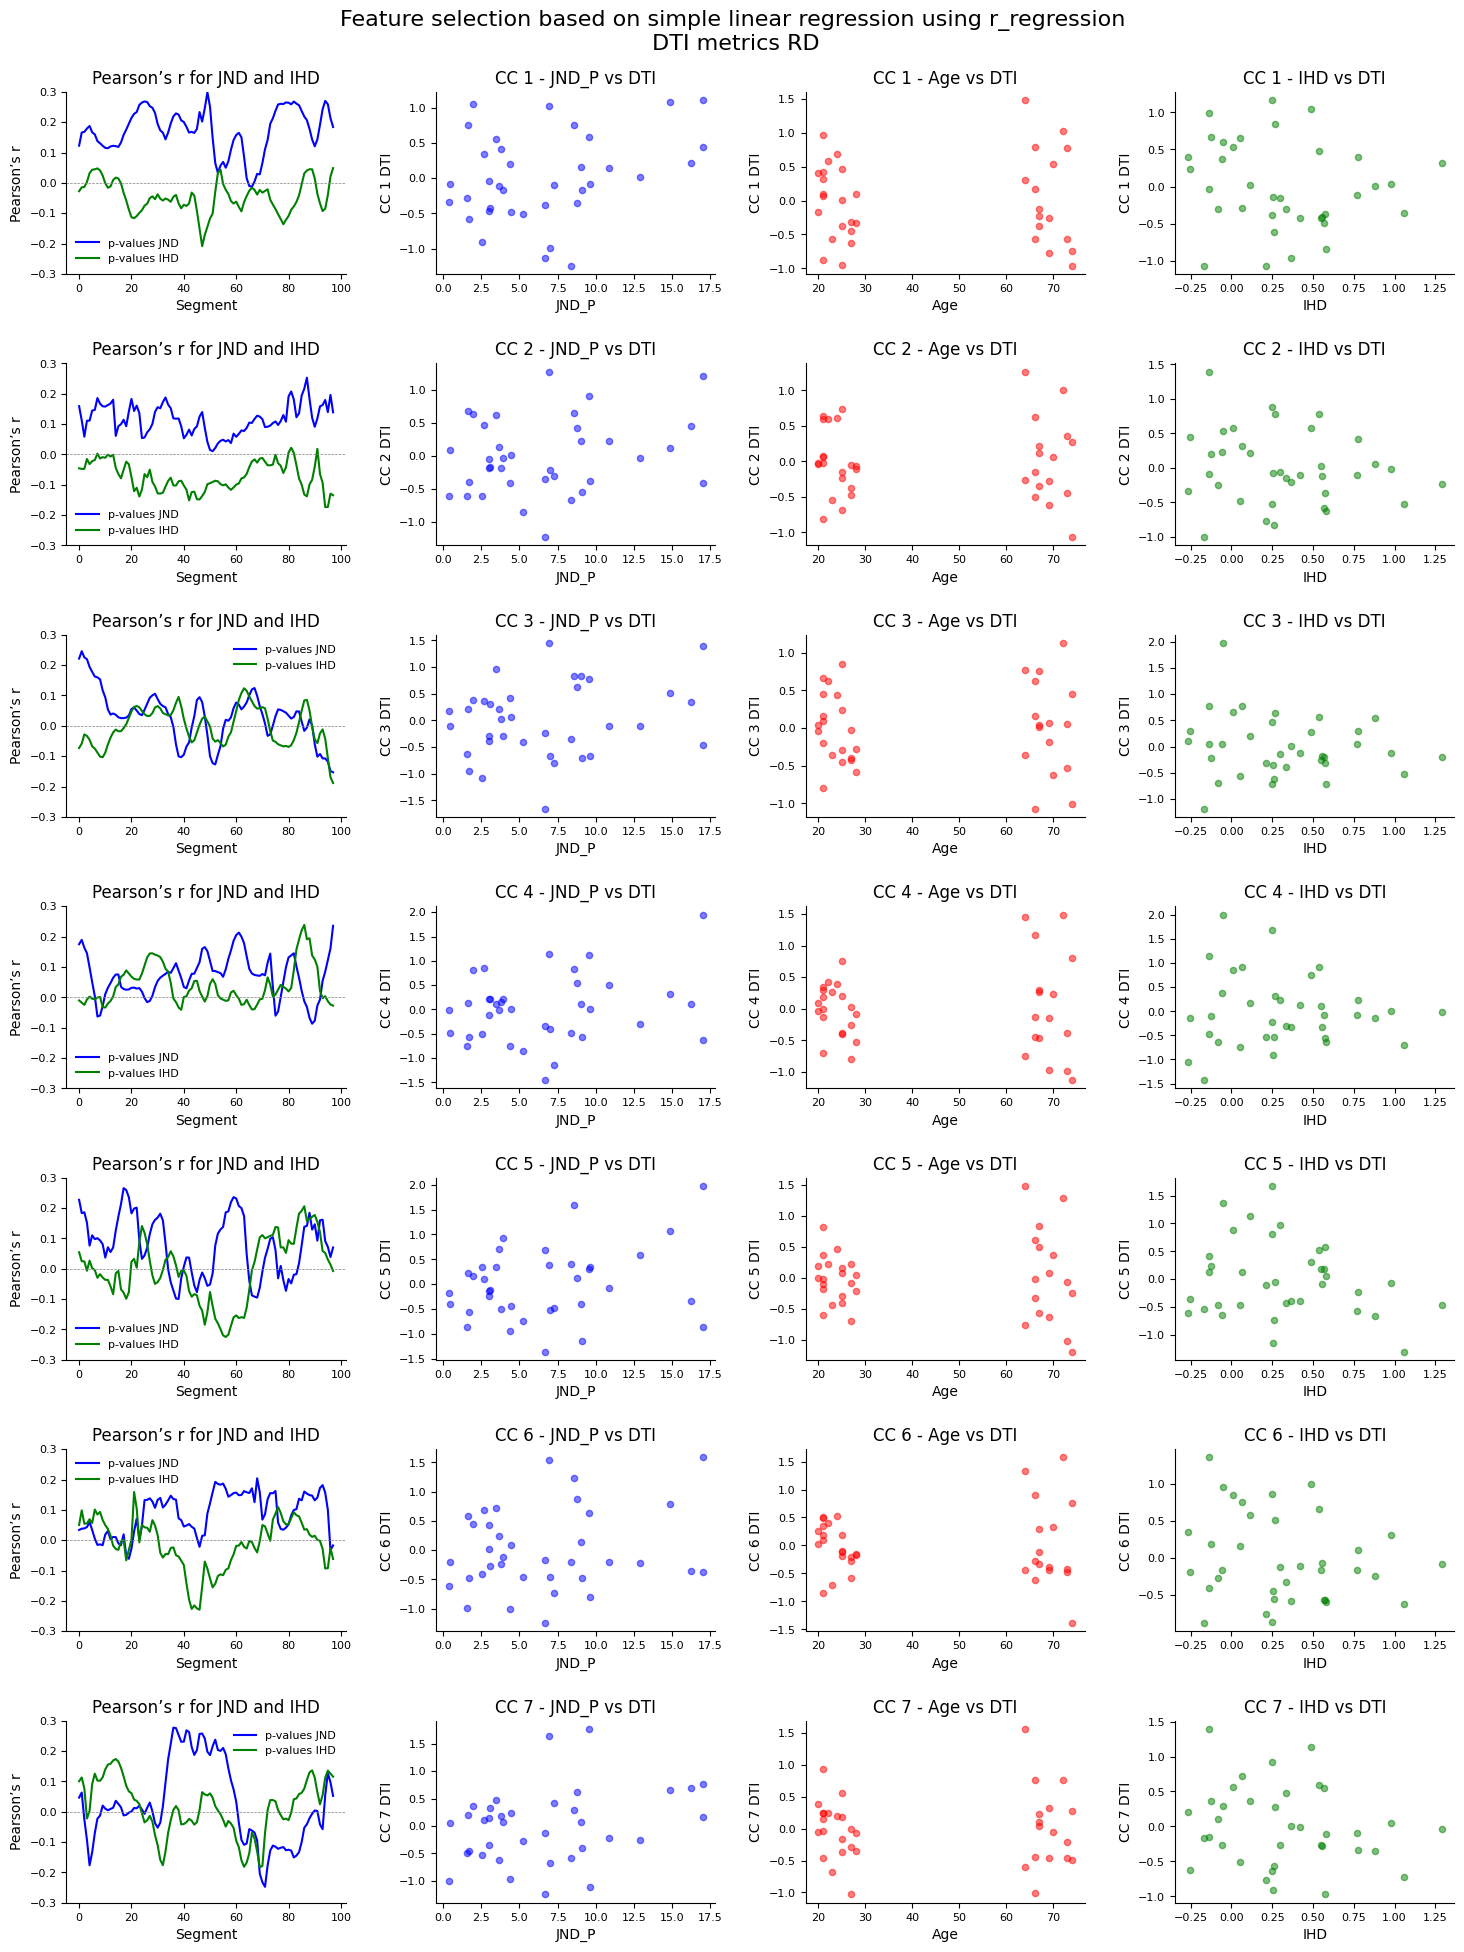

In [361]:
## PEARSON'S R VALUES

fig5, axs = plt.subplots(nrows=7, ncols=4, figsize=(15, 20))

for cc in range(1,8):   

    axs[cc-1,0].plot(r_reg_jnd[cc-1,:], color='blue', label='p-values JND')
    axs[cc-1,0].plot(r_reg_ihd[cc-1,:], color='green', label='p-values IHD')
    axs[cc-1,0].set_ylim(-0.3,0.3)
    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('Pearson’s r')   
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('Pearson’s r for JND and IHD')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)
    axs[cc-1,0].axhline(0, color='gray', linestyle='--', linewidth=0.5)

    axs[cc-1,1].scatter(jnd, DTI_adjusted[:,bestfeat_jnd_r[cc-1,:] ,cc-1].mean(axis=1), color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_adjusted[:,bestfeat_age_r[cc-1,:] ,cc-1].mean(axis=1), color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,3].scatter(ihd, DTI_adjusted[:,bestfeat_ihd_r[cc-1,:] ,cc-1].mean(axis=1), color='green', label='Données', alpha=0.5, s=20)

    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,3].set_xlabel('IHD')
    axs[cc-1,3].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,3].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,3].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')
    axs[cc-1,3].set_title(f'CC {cc} - IHD vs DTI')

fig5.suptitle('Feature selection based on simple linear regression using r_regression\n DTI metrics {}'.format(metricsDTI), fontsize=16)
    
plt.tight_layout(pad=2.0) 

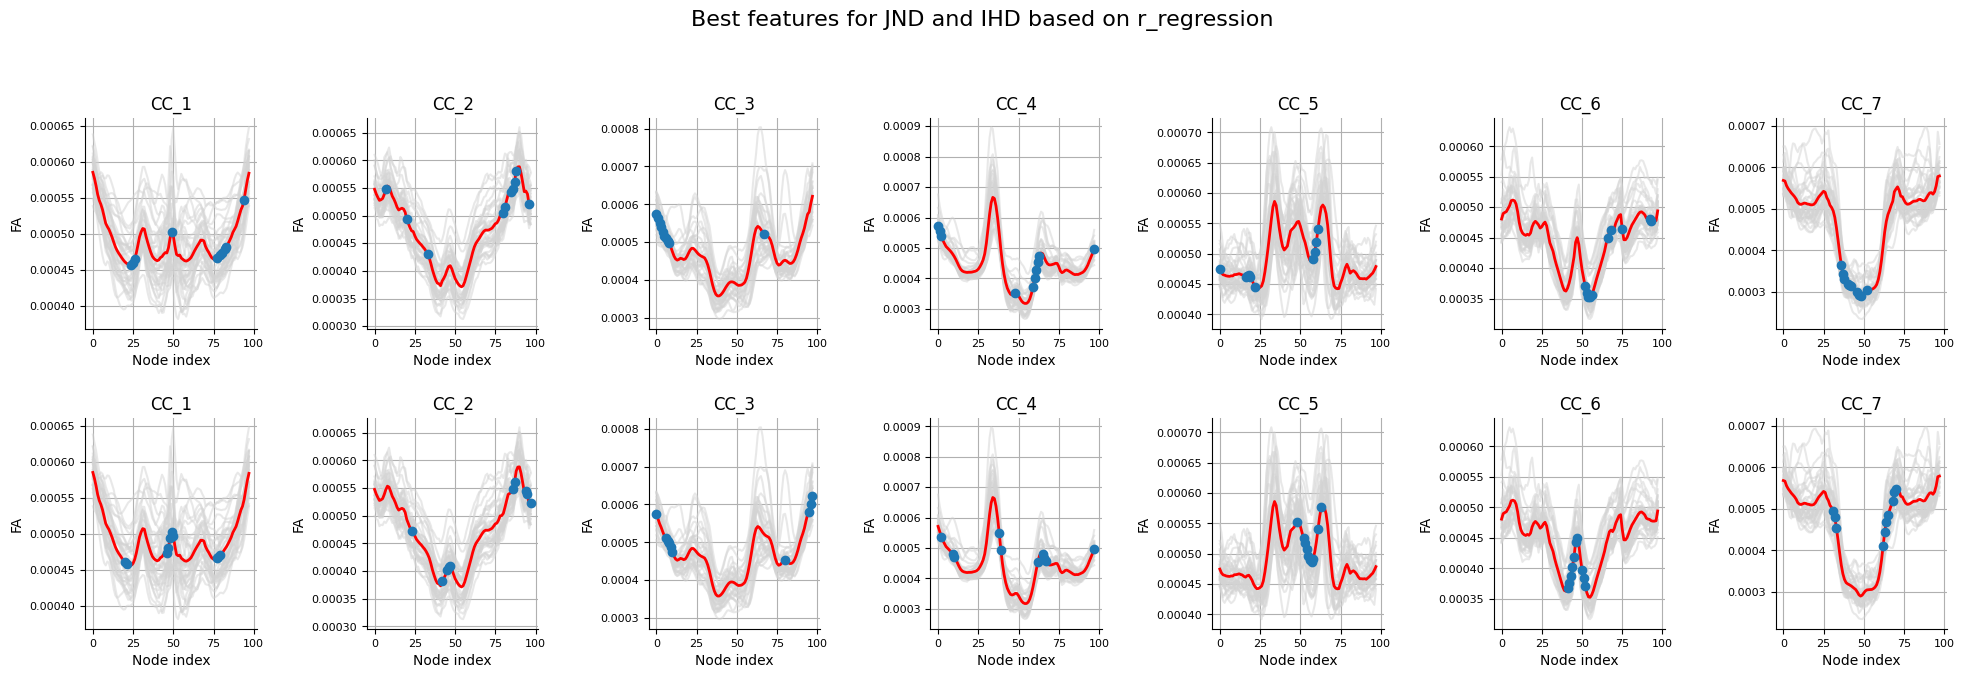

In [362]:

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig6, axs = plt.subplots(nrows=2, ncols=7, figsize=(20, 7))

  
for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[0,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[0,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[0,i].plot(r_reg_best_features_jnd_cc_allCC[i,:], DTI[:,r_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features JND')
    axs[0,i].set_xlabel('Node index')
    axs[0,i].set_ylabel('FA')
    axs[0,i].grid(True)
    axs[0,i].spines['top'].set_visible(False)
    axs[0,i].spines['right'].set_visible(False)
    axs[0,i].set_title(CCx)

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[1,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[1,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[1,i].plot(r_reg_best_features_ihd_cc_allCC[i,:], DTI[:,r_reg_best_features_ihd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features IHD')
    axs[1,i].set_xlabel('Node index')
    axs[1,i].set_ylabel('FA')
    axs[1,i].grid(True)
    axs[1,i].spines['top'].set_visible(False)
    axs[1,i].spines['right'].set_visible(False)
    axs[1,i].set_title(CCx)

fig6.suptitle('Best features for JND and IHD based on r_regression\n', fontsize=16)
plt.tight_layout(pad=2.0)



In [363]:

DTI_JND_r=pd.DataFrame([])
DTI_AGE_r=pd.DataFrame([])
DTI_IHD_r=pd.DataFrame([])

DTI_JND_f=pd.DataFrame([])
DTI_AGE_f=pd.DataFrame([])
DTI_IHD_f=pd.DataFrame([])

for cc in range(1,8):
    DTI_JND_tmp=pd.DataFrame(DTI_adjusted[:,bestfeat_jnd_r[cc-1],cc-1])
    DTI_JND_tmp.columns = [f'CC{cc}_{idx}' for idx in bestfeat_jnd_r[cc-1]]
    DTI_JND_r=pd.concat([DTI_JND_r, DTI_JND_tmp], axis=1)

    DTI_AGE_tmp=pd.DataFrame(DTI_adjusted[:,bestfeat_age_r[cc-1],cc-1])
    DTI_AGE_tmp.columns = [f'CC{cc}_{idx}' for idx in bestfeat_age_r[cc-1]]
    DTI_AGE_r=pd.concat([DTI_AGE_r, DTI_AGE_tmp], axis=1)

    DTI_IHD_tmp=pd.DataFrame(DTI_adjusted[:,bestfeat_ihd_r[cc-1],cc-1])
    DTI_IHD_tmp.columns = [f'CC{cc}_{idx}' for idx in bestfeat_ihd_r[cc-1]]
    DTI_IHD_r=pd.concat([DTI_IHD_r, DTI_IHD_tmp], axis=1)

    DTI_JND_tmp=pd.DataFrame(DTI_adjusted[:,bestfeat_jnd_f[cc-1],cc-1])
    DTI_JND_tmp.columns = [f'CC{cc}_{idx}' for idx in bestfeat_jnd_f[cc-1]]
    DTI_JND_f=pd.concat([DTI_JND_f, DTI_JND_tmp], axis=1)

    DTI_AGE_tmp=pd.DataFrame(DTI_adjusted[:,bestfeat_age_f[cc-1],cc-1])
    DTI_AGE_tmp.columns = [f'CC{cc}_{idx}' for idx in bestfeat_age_f[cc-1]]
    DTI_AGE_f=pd.concat([DTI_AGE_f, DTI_AGE_tmp], axis=1)

    DTI_IHD_tmp=pd.DataFrame(DTI_adjusted[:,bestfeat_ihd_f[cc-1],cc-1])
    DTI_IHD_tmp.columns = [f'CC{cc}_{idx}' for idx in bestfeat_ihd_f[cc-1]]
    DTI_IHD_f=pd.concat([DTI_IHD_f, DTI_IHD_tmp], axis=1)



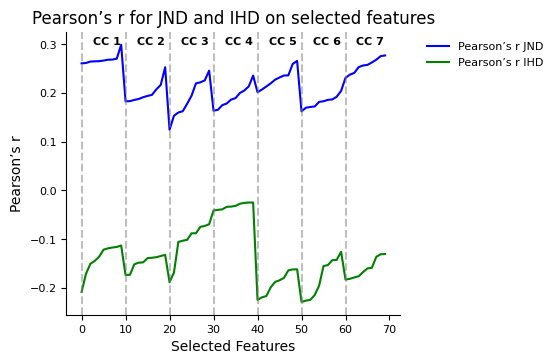

In [364]:
r_reg_jnd70 = r_regression(DTI_JND_r, jnd)
r_reg_ihd70 = r_regression(DTI_IHD_r, ihd)

fig7, ax7 = plt.subplots(figsize=(6, 4))
ax7.plot(r_reg_jnd70, color='blue', label='Pearson’s r JND')
ax7.plot(r_reg_ihd70, color='green', label='Pearson’s r IHD')
ax7.set_xlabel('Selected Features')
ax7.set_ylabel('Pearson’s r')
ax7.set_title('Pearson’s r for JND and IHD on selected features')
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
ax7.legend(bbox_to_anchor=(1.05, 1), loc='upper left')     

for i in range(7):
    ax7.axvline(x=i*10, color='gray', linestyle='--', alpha=0.5)
    ax7.text(i*10 + 2.5, max(max(r_reg_jnd70), 0), f'CC {i+1}', color='black', fontsize=8,weight='bold')
    
plt.tight_layout(pad=2.0)

In [365]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score

Aging_INDICES['JND_group3'] = pd.qcut(Aging_INDICES['JND_P'], q=3, labels=[0,1,2])
Aging_INDICES['IHD_group3'] = pd.qcut(Aging_INDICES['IHD'], q=3, labels=[0,1,2])

jnd_grouped = pd.qcut(jnd, q=2, labels=[0, 1])
age_grouped = pd.qcut(age, q=2, labels=[0, 1])
ihd_grouped = pd.qcut(ihd, q=2, labels=[0, 1])


colors = sns.color_palette('Set2')
first_color = colors[0]
second_color = colors[1]



CC 1: P-value for the overall model: 0.0733
CC 2: P-value for the overall model: 0.1978
CC 3: P-value for the overall model: 0.2079
CC 4: P-value for the overall model: 0.1822
CC 5: P-value for the overall model: 0.1257
CC 6: P-value for the overall model: 0.2477
CC 7: P-value for the overall model: 0.0771
CC 1: P-value for the overall model: 0.3577
CC 2: P-value for the overall model: 0.3479
CC 3: P-value for the overall model: 0.4250
CC 4: P-value for the overall model: 0.8260
CC 5: P-value for the overall model: 0.2174
CC 6: P-value for the overall model: 0.2481
CC 7: P-value for the overall model: 0.2641


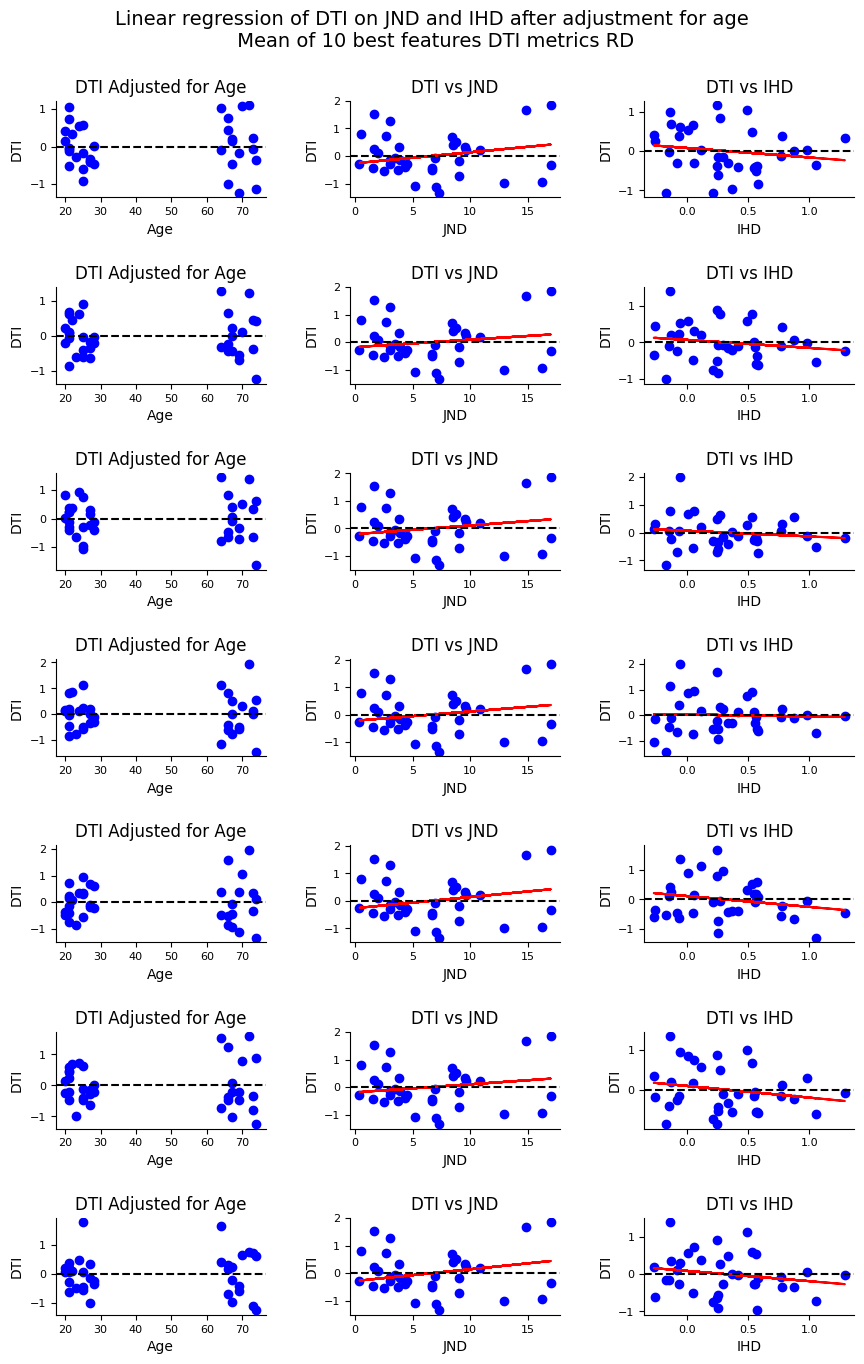

In [366]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


data_to_use_jnd=DTI_JND_r  # or DTI_JND_f depending on the feature selection method used
data_to_use_ihd=DTI_IHD_r  # or DTI_IHD_f depending on the feature selection method used

fig8, axs = plt.subplots(nrows=7, ncols=3, figsize=(9,14))

for cc in range(1,8):
        
    data_adjusted_jnd = data_to_use_jnd[data_to_use_jnd.columns[10*(cc-1):10*(cc-1)+10].tolist()].mean(axis=1)
    data_adjusted_ihd = data_to_use_ihd[data_to_use_ihd.columns[10*(cc-1):10*(cc-1)+10].tolist()].mean(axis=1)

    X = sm.add_constant(jnd)
    
    y = data_adjusted_jnd.values

    model = sm.OLS(y, X)
    results = model.fit()
    slope = results.params[1]
    intercept = results.params[0]
    regression_line = slope * jnd + intercept

    axs[cc-1,0].scatter(age, data_adjusted_jnd, label='DTI Adjusted',color='blue')
    axs[cc-1,0].set_xlabel('Age')
    axs[cc-1,0].set_ylabel('DTI')
    axs[cc-1,0].axhline(0, color='black', linestyle='--', label='Zero Line')
    axs[cc-1,0].set_title('DTI Adjusted for Age')

    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

    axs[cc-1,1].scatter(jnd, data_adjusted, color='blue', label='Données')
    axs[cc-1,1].plot(jnd, regression_line, color='red')
    axs[cc-1,1].set_xlabel('JND')
    axs[cc-1,1].set_ylabel('DTI')
    axs[cc-1,1].set_title('DTI vs JND')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,1].axhline(0, color='black', linestyle='--', label='Zero Line')

    # Afficher le graphique
    # print(results.summary())
    f_pvalue = results.f_pvalue
    print(f'CC {cc}: P-value for the overall model: {f_pvalue:.4f}')




for cc in range(1,8):
        
    data_adjusted_ihd = data_to_use_ihd[data_to_use_ihd.columns[10*(cc-1):10*(cc-1)+10].tolist()].mean(axis=1)

    X = sm.add_constant(ihd)
    
    y = data_adjusted_ihd.values

    model = sm.OLS(y, X)
    results = model.fit()
    slope = results.params[1]
    intercept = results.params[0]
    regression_line = slope * ihd + intercept

    axs[cc-1,2].scatter(ihd, data_adjusted_ihd, color='blue', label='Données')
    axs[cc-1,2].plot(ihd, regression_line, color='red')
    axs[cc-1,2].set_xlabel('IHD')
    axs[cc-1,2].set_ylabel('DTI')
    axs[cc-1,2].set_title('DTI vs IHD')
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,2].axhline(0, color='black', linestyle='--', label='Zero Line')

    # Afficher le graphique
    # print(results.summary())
    f_pvalue = results.f_pvalue
    print(f'CC {cc}: P-value for the overall model: {f_pvalue:.4f}')

fig8.suptitle('Linear regression of DTI on JND and IHD after adjustment for age\n Mean of 10 best features DTI metrics {}'.format(metricsDTI), fontsize=14)


plt.tight_layout(pad=2.0)


_____________________RD_____________________
________________________________________
RD  \ segment cc:  1 [49, 94, 25, 82, 26, 79, 24, 80, 83, 77]
p-value  pour cc 1: 0.0183
p-value bonf. corrected pour cc 1: 0.128 ❌
________________________________________
RD  \ segment cc:  2 [87, 86, 81, 96, 85, 80, 33, 7, 88, 20]
p-value  pour cc 2: 0.0926
p-value bonf. corrected pour cc 2: 0.648 ❌
________________________________________
RD  \ segment cc:  3 [1, 2, 0, 3, 4, 5, 6, 7, 97, 8]
p-value  pour cc 3: 0.1
p-value bonf. corrected pour cc 3: 0.701 ❌
________________________________________
RD  \ segment cc:  4 [97, 61, 60, 62, 1, 59, 63, 0, 48, 2]
p-value  pour cc 4: 0.0813
p-value bonf. corrected pour cc 4: 0.569 ❌
________________________________________
RD  \ segment cc:  5 [17, 18, 59, 19, 60, 0, 58, 16, 61, 22]
p-value  pour cc 5: 0.0447
p-value bonf. corrected pour cc 5: 0.313 ❌
________________________________________
RD  \ segment cc:  6 [68, 52, 55, 53, 54, 93, 92, 66, 56, 75]
p-va

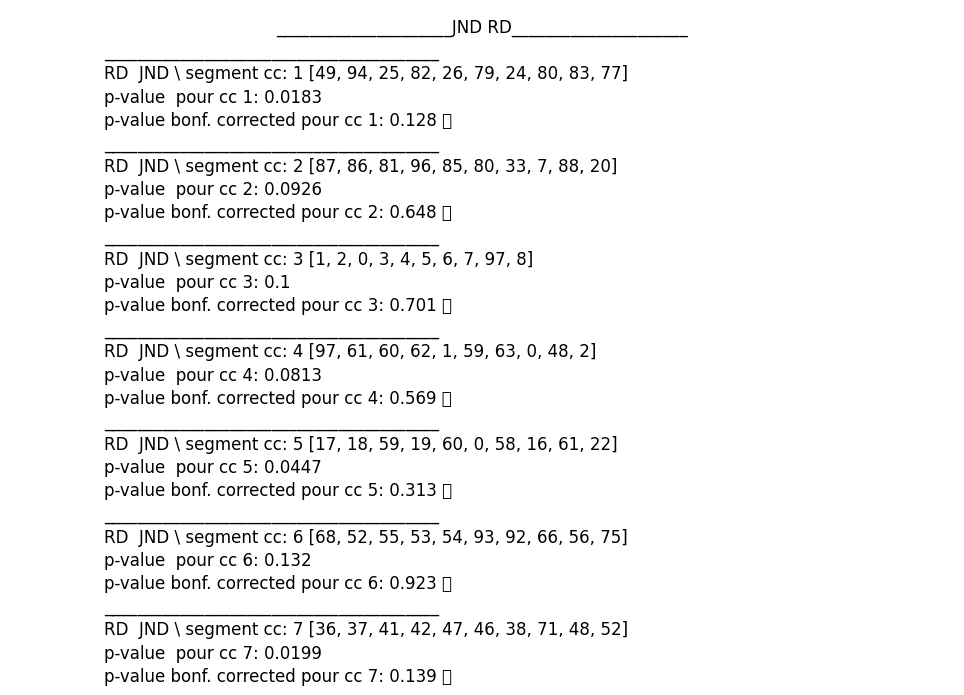

In [367]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

pvaDTIlue = []

nseg=10

data_to_use_jnd=DTI_JND_r  # or DTI_JND_f depending on the feature selection method used
data_to_use_ihd=DTI_IHD_r  # or DTI_IHD_f depending on the feature selection method used

for cc in range(1,8):

    data = data_to_use_jnd[data_to_use_jnd.columns[10*(cc-1):10*(cc-1)+nseg].tolist()].mean(axis=1)

    np.random.seed(42)
    n = 100
    df = pd.DataFrame({
        'DTI': data,  # Variable indépendante
        'age': age,  # Variable de contrôle
        'jnd': jnd,   # Variable dépendante
        'ihd': ihd   # Variable dépendante
    })

    # 2. Préparer les variables pour la régression
    X = df[['DTI', 'age']]  # Variables explicatives
    X = sm.add_constant(X)  # Ajoute une constante pour l'interception
    y = df['jnd']  # Variable à expliquer

    # 3. Ajuster le modèle de régression multiple
    model = sm.OLS(y, X).fit()

    pvaDTIlue.append(model.pvalues['DTI'])

# print(model.summary())

# # 4. Afficher les résultats de manière claire
# print("\n--- Résultats de la régression ---")
# print(f"Coefficient du DTI : {model.params['DTI']:.4f}")
# print(f"P-valeur du DTI : {model.pvalues['DTI']:.4f}")
# print(f"Coefficient de l'âge : {model.params['age']:.4f}")
# print(f"P-valeur de l'âge : {model.pvalues['age']:.4f}")
# print(f"R-carré : {model.rsquared:.3f}")
# print(f"F-statistique : {model.fvalue:.2f} (p-valeur : {model.f_pvalue:.4f})")

import emoji

print('_____________________' + metricsDTI+ '_____________________')
for cc in range(7):
    print('________________________________________')
    print(metricsDTI + '  \ segment cc: ', cc+1, f_reg_best_features_jnd_cc_allCC[cc,:].tolist())
    print('p-value  pour cc {}: {:.3}'.format(cc+1, pvaDTIlue[cc] ))
    if pvaDTIlue[cc] * 7 < 0.05:
        emojipv=emoji.emojize(':check_mark_button:')
    else:        emojipv=emoji.emojize(':cross_mark:')
    print('p-value bonf. corrected pour cc {}: {:.3f}'.format(cc+1, pvaDTIlue[cc] * 7), emojipv)



fig9, ax = plt.subplots(figsize=(10, 8))

# Hide the axes
ax.axis('off')

# Add the title to the figure
ax.text(0.5, 0.95, '_____________________JND ' + metricsDTI + '_____________________', fontsize=12, ha='center')

# Add the statistical results to the figure
y_position = 0.9
for cc in range(7):
    ax.text(0.1, y_position, '________________________________________', fontsize=12)
    y_position -= 0.05
    ax.text(0.1, y_position, metricsDTI + '  JND \ segment cc: ' + str(cc+1) + ' ' + str(f_reg_best_features_jnd_cc_allCC[cc,:].tolist()), fontsize=12)
    y_position -= 0.05
    ax.text(0.1, y_position, 'p-value  pour cc {}: {:.3}'.format(cc+1, pvaDTIlue[cc]), fontsize=12)
    y_position -= 0.05
    if pvaDTIlue[cc] * 7 < 0.05:
        emojipv = emoji.emojize(':check_mark_button:')
    else:
        emojipv = emoji.emojize(':cross_mark:')
    ax.text(0.1, y_position, 'p-value bonf. corrected pour cc {}: {:.3f} {}'.format(cc+1, pvaDTIlue[cc] * 7, emojipv), fontsize=12)
    y_position -= 0.05
plt.tight_layout(pad=2.0)

# Show the figure
plt.show()

_____________________IHD RD_____________________
________________________________________
RD  \ segment cc:  1 [47, 48, 46, 49, 78, 79, 77, 50, 21, 20]
p-value  pour cc 1: 0.229
p-value bonf. corrected pour cc 1: 1.602 ❌
________________________________________
RD  \ segment cc:  2 [94, 95, 42, 46, 45, 23, 87, 47, 97, 86]
p-value  pour cc 2: 0.219
p-value bonf. corrected pour cc 2: 1.535 ❌
________________________________________
RD  \ segment cc:  3 [97, 96, 63, 64, 62, 95, 9, 8, 65, 38]
p-value  pour cc 3: 0.896
p-value bonf. corrected pour cc 3: 6.274 ❌
________________________________________
RD  \ segment cc:  4 [86, 85, 88, 87, 84, 83, 28, 27, 29, 89]
p-value  pour cc 4: 0.116
p-value bonf. corrected pour cc 4: 0.813 ❌
________________________________________
RD  \ segment cc:  5 [56, 55, 57, 86, 54, 85, 58, 48, 84, 53]
p-value  pour cc 5: 0.435
p-value bonf. corrected pour cc 5: 3.046 ❌
________________________________________
RD  \ segment cc:  6 [46, 43, 45, 44, 42, 21, 51, 47

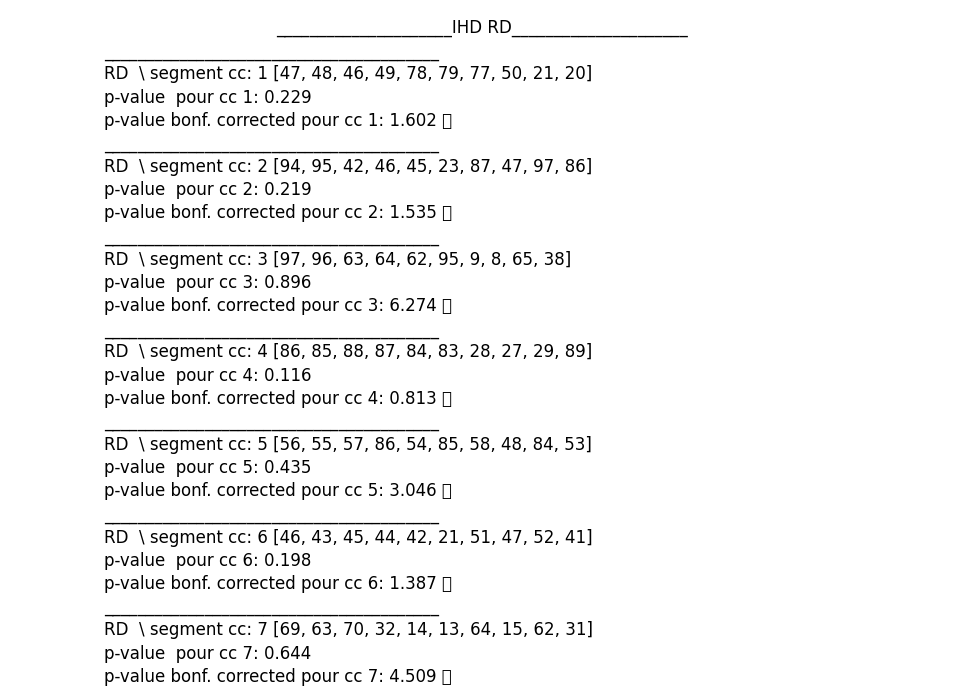

In [368]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

pvaDTIlue = []

nseg=10

data_to_use_ihd=DTI_IHD_f  # or DTI_IHD_f depending on the feature selection method used

for cc in range(1,8):

    data = data_to_use_ihd[data_to_use_ihd.columns[10*(cc-1):10*(cc-1)+nseg].tolist()].mean(axis=1)

    np.random.seed(42)
    n = 100
    df = pd.DataFrame({
        'DTI': data,  # Variable indépendante
        'age': age,  # Variable de contrôle
        'jnd': jnd,   # Variable dépendante
        'ihd': ihd   # Variable dépendante
    })

    # 2. Préparer les variables pour la régression
    X = df[['DTI', 'age']]  # Variables explicatives
    X = sm.add_constant(X)  # Ajoute une constante pour l'interception
    y = df['ihd']  # Variable à expliquer

    # 3. Ajuster le modèle de régression multiple
    model = sm.OLS(y, X).fit()

    pvaDTIlue.append(model.pvalues['DTI'])

# print(model.summary())

# # 4. Afficher les résultats de manière claire
# print("\n--- Résultats de la régression ---")
# print(f"Coefficient du DTI : {model.params['DTI']:.4f}")
# print(f"P-valeur du DTI : {model.pvalues['DTI']:.4f}")
# print(f"Coefficient de l'âge : {model.params['age']:.4f}")
# print(f"P-valeur de l'âge : {model.pvalues['age']:.4f}")
# print(f"R-carré : {model.rsquared:.3f}")
# print(f"F-statistique : {model.fvalue:.2f} (p-valeur : {model.f_pvalue:.4f})")

# 5. Visualisation


import emoji


print('_____________________IHD ' + metricsDTI + '_____________________')
for cc in range(7):
    print('________________________________________')
    print(metricsDTI + '  \ segment cc: ', cc+1, f_reg_best_features_ihd_cc_allCC[cc,:].tolist())
    print('p-value  pour cc {}: {:.3}'.format(cc+1, pvaDTIlue[cc] ))
    if pvaDTIlue[cc] * 7 < 0.05:
        emojipv=emoji.emojize(':check_mark_button:')
    else:        emojipv=emoji.emojize(':cross_mark:')
    print('p-value bonf. corrected pour cc {}: {:.3f}'.format(cc+1, pvaDTIlue[cc] * 7), emojipv)

fig10, ax = plt.subplots(figsize=(10, 8))

# Hide the axes
ax.axis('off')

# Add the title to the figure
ax.text(0.5, 0.95, '_____________________IHD ' + metricsDTI + '_____________________', fontsize=12, ha='center')

# Add the statistical results to the figure
y_position = 0.9
for cc in range(7):
    ax.text(0.1, y_position, '________________________________________', fontsize=12)
    y_position -= 0.05
    ax.text(0.1, y_position, metricsDTI + '  \ segment cc: ' + str(cc+1) + ' ' + str(f_reg_best_features_ihd_cc_allCC[cc,:].tolist()), fontsize=12)
    y_position -= 0.05
    ax.text(0.1, y_position, 'p-value  pour cc {}: {:.3}'.format(cc+1, pvaDTIlue[cc]), fontsize=12)
    y_position -= 0.05
    if pvaDTIlue[cc] * 7 < 0.05:
        emojipv = emoji.emojize(':check_mark_button:')
    else:
        emojipv = emoji.emojize(':cross_mark:')
    ax.text(0.1, y_position, 'p-value bonf. corrected pour cc {}: {:.3f} {}'.format(cc+1, pvaDTIlue[cc] * 7, emojipv), fontsize=12)
    y_position -= 0.05
    
plt.tight_layout(pad=2.0)

# Show the figure
plt.show()

In [369]:
f_reg_best_features_jnd_cc_allCC

array([[49, 94, 25, 82, 26, 79, 24, 80, 83, 77],
       [87, 86, 81, 96, 85, 80, 33,  7, 88, 20],
       [ 1,  2,  0,  3,  4,  5,  6,  7, 97,  8],
       [97, 61, 60, 62,  1, 59, 63,  0, 48,  2],
       [17, 18, 59, 19, 60,  0, 58, 16, 61, 22],
       [68, 52, 55, 53, 54, 93, 92, 66, 56, 75],
       [36, 37, 41, 42, 47, 46, 38, 71, 48, 52]])

In [370]:
f_reg_best_features_ihd_cc_allCC

array([[47, 48, 46, 49, 78, 79, 77, 50, 21, 20],
       [94, 95, 42, 46, 45, 23, 87, 47, 97, 86],
       [97, 96, 63, 64, 62, 95,  9,  8, 65, 38],
       [86, 85, 88, 87, 84, 83, 28, 27, 29, 89],
       [56, 55, 57, 86, 54, 85, 58, 48, 84, 53],
       [46, 43, 45, 44, 42, 21, 51, 47, 52, 41],
       [69, 63, 70, 32, 14, 13, 64, 15, 62, 31]])

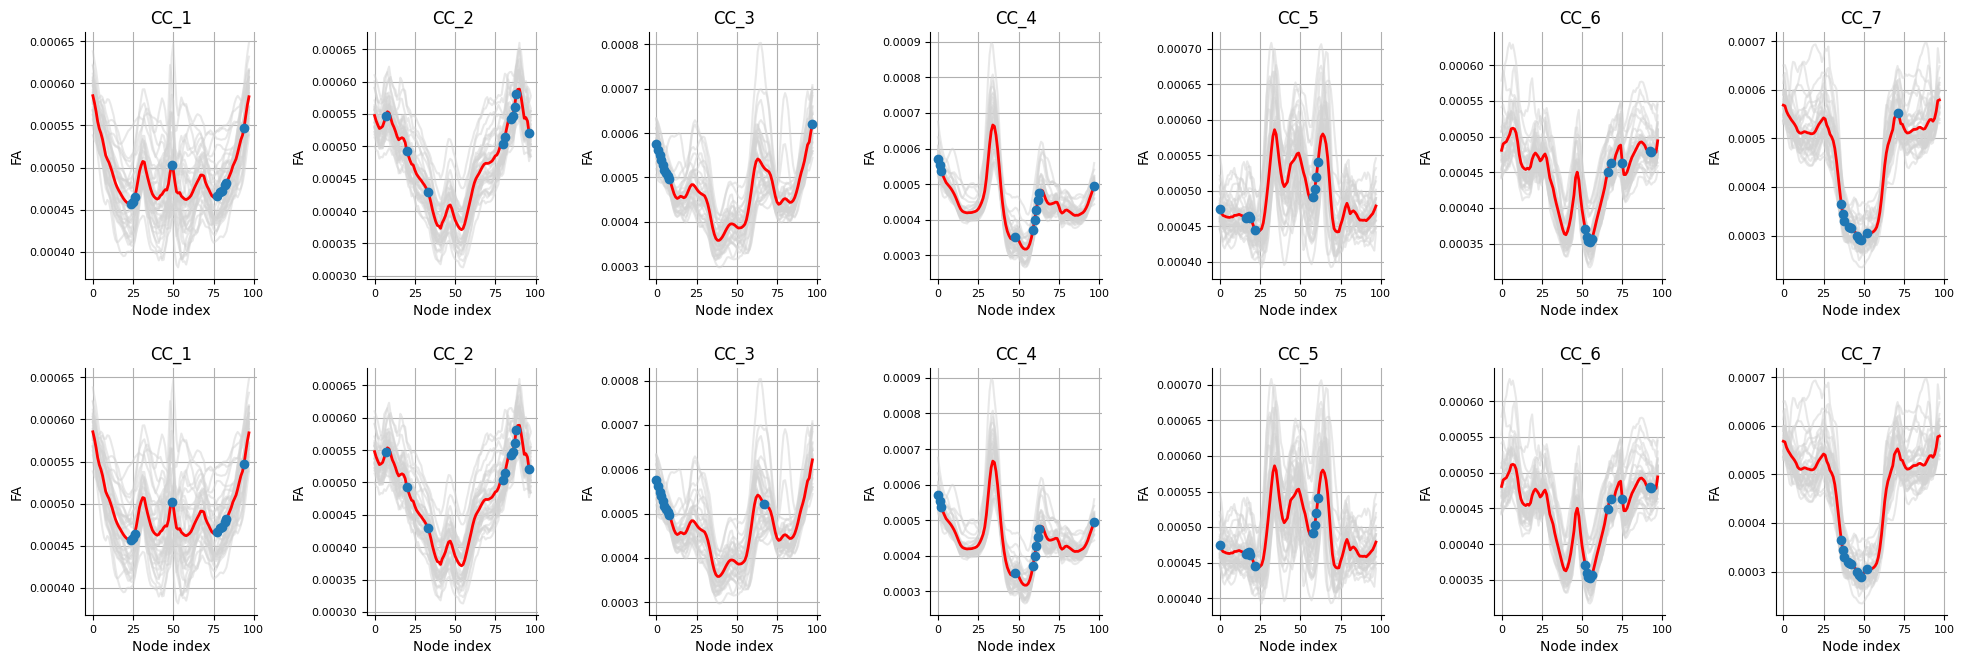

In [371]:

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=7, figsize=(20, 7))

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[0,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[0,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[0,i].plot(f_reg_best_features_jnd_cc_allCC[i,:], DTI[:,f_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features Age')
    axs[0,i].set_xlabel('Node index')
    axs[0,i].set_ylabel('FA')
    axs[0,i].grid(True)
    axs[0,i].spines['top'].set_visible(False)
    axs[0,i].spines['right'].set_visible(False)
    axs[0,i].set_title(CCx)
   

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[1,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[1,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[1,i].plot(r_reg_best_features_jnd_cc_allCC[i,:], DTI[:,r_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features JND')
    axs[1,i].set_xlabel('Node index')
    axs[1,i].set_ylabel('FA')
    axs[1,i].grid(True)
    axs[1,i].spines['top'].set_visible(False)
    axs[1,i].spines['right'].set_visible(False)
    axs[1,i].set_title(CCx)

plt.tight_layout(pad=2.0)


IHD

In [372]:
print(os.getcwd())

titre_pdf='Figures JND and IHD metrics DTI ' + metricsDTI + '.pdf'
with PdfPages(titre_pdf) as pdf:
    pdf.savefig(fig1)  # Ajoute la première figure
    pdf.savefig(fig2)  # Ajoute la deuxième figure
    pdf.savefig(fig3)  # Ajoute la troisième figure
    pdf.savefig(fig4)  # Ajoute la quatrième figure
    pdf.savefig(fig5)  # Ajoute la cinquième figure
    pdf.savefig(fig6)  # Ajoute la sixième figure
    pdf.savefig(fig7)  # Ajoute la septième figure
    pdf.savefig(fig8)  # Ajoute la huitième figure
    pdf.savefig(fig9)  # Ajoute la neuvième figure
    pdf.savefig(fig10)  # Ajoute la dixième figure

/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC
